# Day 07 — Project: Wasel

Randa runs operations analytics at Wasel, the ride-hailing app expanding across Egypt. Leadership has a fixed budget for driver incentives next quarter and wants her recommendation on which cities actually need it — plus a read on whether the promo codes marketing keeps pushing are paying for themselves, and whether a coverage gap someone flagged in a meeting is real or a false alarm.

No new SQL syntax in this project: it's Days 01-05 (filtering, aggregation, JOINs, CASE, anti-joins, subqueries, CTEs, views, temp tables, window functions) applied to a fresh dataset that wasn't built with any of these exact questions in mind.

## Getting connected

In [1]:
%load_ext sql

In [2]:
%sql sqlite:///../Databases/wasel.sqlite --alias wasel

Connecting to 'wasel'

A bare connection string, no SQLAlchemy needed — same Option 2 pattern as every project day since Day 06.

In [3]:
%%sql
SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;

Running query in 'wasel'

name
cities
driver_city_coverage
drivers
promotions
ratings
riders
trips
vehicle_types
vehicles


9 tables — cities, drivers, riders, `driver_city_coverage` (the genuine N:N — a driver can cover more than one city), vehicle_types, vehicles, promotions, trips (the transactional core), and ratings. A quick preview of each before Randa's questions start:

In [4]:
from IPython.display import Markdown, display

tables_result = %sql SELECT name FROM sqlite_master WHERE type='table' ORDER BY name
table_names = tables_result.DataFrame()['name'].tolist()

for table in table_names:
    display(Markdown(f"### {table}"))
    preview = %sql SELECT * FROM {{table}} LIMIT 3
    display(preview)

Running query in 'wasel'

### cities

Running query in 'wasel'

city_id,city_name
1,Cairo
2,Giza
3,Alexandria


### driver_city_coverage

...

Running query in 'wasel'

type_id,type_name,base_fare,per_km_rate
1,Economy,12.0,3.5
2,Comfort,18.0,4.75
3,XL,25.0,6.0


### vehicles

Running query in 'wasel'

vehicle_id,driver_id,type_id,make,model,year,plate_number
1,1,1,Skoda,Rapid,2015,RNX 554
2,2,1,Chevrolet,Optra,2021,VSU 337
3,3,1,MG,5,2022,ZYE 800


---

Randa opens with the basics — how big is the business, and where does it actually happen.

### Q1 — How many trips has Wasel completed since launch, and how many were cancelled or a no-show?

**Business question:** the headline numbers for the leadership deck's first slide.

In [5]:
%%sql
SELECT status, COUNT(*) AS num_trips
FROM trips
GROUP BY status
ORDER BY num_trips DESC;

Running query in 'wasel'

status,num_trips
completed,5144
cancelled,622
no_show,234


### Q2 — Which 5 cities have generated the most completed trips?

**Business question:** where the volume already is, before deciding where the *gaps* are.

In [6]:
%%sql
SELECT c.city_name, COUNT(*) AS completed_trips
FROM trips t
JOIN cities c ON t.pickup_city_id = c.city_id
WHERE t.status = 'completed'
GROUP BY c.city_name
ORDER BY completed_trips DESC
LIMIT 5;

Running query in 'wasel'

city_name,completed_trips
Cairo,1682
Giza,1275
Alexandria,612
Sharqia,492
Qalyubia,407


### Q3 — What's the average completed-trip fare, company-wide?

**Business question:** a single reference number everything else in the deck gets compared against.

In [7]:
%%sql
SELECT ROUND(AVG(fare_amount), 2) AS avg_fare
FROM trips
WHERE status = 'completed';

Running query in 'wasel'

avg_fare
97.56


Next: whether two things marketing keeps asking about — promo codes and surge pricing — are actually significant, or just noise.

### Q4 — Which promo codes have actually been redeemed, and how many times each?

**Business question:** marketing wants to know which of this quarter's codes are pulling their weight before planning the next batch.

In [8]:
%%sql
SELECT p.code, COUNT(*) AS times_used
FROM trips t
JOIN promotions p ON t.promo_id = p.promo_id
GROUP BY p.code
ORDER BY times_used DESC
LIMIT 5;

Running query in 'wasel'

code,times_used
WEEKEND72,110
SUMMER88,28
WEEKEND50,27
EID73,20
WEEKEND66,12


### Q5 — Are surge-priced trips a big share of the business, or a rare event?

**Business question:** riders complain about surge pricing loudly — worth checking whether it's actually common before it becomes a policy fight.

In [9]:
%%sql
SELECT CASE WHEN surge_multiplier > 1 THEN 'Surge' ELSE 'Normal' END AS pricing,
       COUNT(*) AS num_trips
FROM trips
WHERE status = 'completed'
GROUP BY pricing;

Running query in 'wasel'

pricing,num_trips
Normal,3614
Surge,1530


With the shape of the business established, Randa turns to the drivers themselves — who's carrying the business, and who isn't showing up at all.

### Q6 — Combine every completed trip with the driver who drove it, their vehicle, and the vehicle type.

**Business question:** the base join every driver-level question from here on builds on.

In [10]:
%%sql
SELECT t.trip_id, d.driver_name, v.make, v.model, vt.type_name
FROM trips t
JOIN drivers d ON t.driver_id = d.driver_id
JOIN vehicles v ON t.vehicle_id = v.vehicle_id
JOIN vehicle_types vt ON v.type_id = vt.type_id
WHERE t.status = 'completed'
LIMIT 5;

Running query in 'wasel'

trip_id,driver_name,make,model,type_name
1,Youssef El-Masry,Toyota,Yaris,Economy
2,Yasmin Farouk,Nissan,Sunny,Economy
3,Osama El-Bahnasy,Renault,Logan,Economy
4,Osama El-Bahnasy,Renault,Logan,Economy
6,Yasmin Farouk,Nissan,Sunny,Economy


### Q7 — Which drivers have never completed a single trip?

**Business question:** the incentive budget is meant for drivers who are *active but under-earning* — not drivers who signed up and never drove. This anti-join tells Randa how many of those there are before she sizes the budget.

In [11]:
%%sql
SELECT d.driver_id, d.driver_name, d.status
FROM drivers d
LEFT JOIN trips t ON d.driver_id = t.driver_id AND t.status = 'completed'
WHERE t.trip_id IS NULL;

Running query in 'wasel'

driver_id,driver_name,status
30,Sherif Sabry,inactive
33,Hala Kamal,inactive
39,Nada Aziz,inactive
41,Magdy Abdel-Latif,inactive
42,Hany Farouk,inactive
51,Omar Abdelrahman,inactive
62,Karim El-Nabawy,inactive
65,Emad Ragab,inactive
68,Hassan Fawzy,inactive
78,Khaled El-Gendy,inactive


**Insight:** worth a look before trusting this number — see Q20 for what it actually means in one specific city.

### Q8 — Bucket every driver into a 'top earner' (over 4,000 EGP total fares) or 'standard' tier.

**Business question:** a quick tier Randa can hand to finance without them re-deriving it.

In [12]:
%%sql
SELECT d.driver_name, SUM(t.fare_amount) AS total_earnings,
       CASE WHEN SUM(t.fare_amount) > 4000 THEN 'top earner' ELSE 'standard' END AS tier
FROM trips t
JOIN drivers d ON t.driver_id = d.driver_id
WHERE t.status = 'completed'
GROUP BY d.driver_id, d.driver_name
ORDER BY total_earnings DESC
LIMIT 10;

Running query in 'wasel'

driver_name,total_earnings,tier
Hossam El-Shazly,7155.21,top earner
Fatma Naguib,6938.53,top earner
Ayman El-Bahnasy,6710.26,top earner
Salma El-Kholy,6072.43,top earner
Mostafa Fahmy,6035.3,top earner
Nesma Hegazy,5741.52,top earner
Sameh Farouk,5666.38,top earner
Salma Kandil,5530.95,top earner
Nada El-Sayed,5169.31,top earner
Bassem Metwally,5162.9800000000005,top earner


### Q9 — Which cities see the highest share of cross-city trips?

**Business question:** cross-city rides (pickup and dropoff in different cities) take longer and tie up a driver further from home — worth knowing which cities lean on them most before setting incentive targets per city.

In [13]:
%%sql
SELECT c.city_name,
       ROUND(100.0 * SUM(CASE WHEN t.pickup_city_id != t.dropoff_city_id THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_cross_city
FROM trips t
JOIN cities c ON t.pickup_city_id = c.city_id
WHERE t.status = 'completed'
GROUP BY c.city_name
ORDER BY pct_cross_city DESC;

Running query in 'wasel'

city_name,pct_cross_city
Giza,17.49
Cairo,17.36
Qalyubia,15.23
Sharqia,0.0
Dakahlia,0.0
Assiut,0.0
Alexandria,0.0


Two more precise questions need reusable definitions, not one-off filters — a subquery, then a saved view.

### Q10 — Which drivers earn above the company-wide average total fare?

**Business question:** "above average" is exactly the kind of threshold that should be computed, not hardcoded — the average shifts every quarter.

In [14]:
%%sql
SELECT driver_id, SUM(fare_amount) AS total_earnings
FROM trips
WHERE status = 'completed'
GROUP BY driver_id
HAVING SUM(fare_amount) > (
    SELECT AVG(driver_total) FROM (
        SELECT SUM(fare_amount) AS driver_total FROM trips WHERE status = 'completed' GROUP BY driver_id
    )
)
ORDER BY total_earnings DESC
LIMIT 10;

Running query in 'wasel'

driver_id,total_earnings
88,7155.21
54,6938.53
178,6710.26
44,6072.43
66,6035.3
87,5741.52
100,5666.38
45,5530.95
17,5169.31
133,5162.9800000000005


### Q11 — Save a 'top 20 drivers by earnings' view for the leadership deck.

**Business question:** this exact ranking gets pulled every quarterly review — define it once.

In [15]:
%%sql
DROP VIEW IF EXISTS top20_drivers;
CREATE VIEW top20_drivers AS
SELECT d.driver_id, d.driver_name, SUM(t.fare_amount) AS total_earnings
FROM trips t
JOIN drivers d ON t.driver_id = d.driver_id
WHERE t.status = 'completed'
GROUP BY d.driver_id, d.driver_name
ORDER BY total_earnings DESC
LIMIT 20;

Running query in 'wasel'

++
||
++
++

In [16]:
%%sql
SELECT * FROM top20_drivers LIMIT 5;

Running query in 'wasel'

driver_id,driver_name,total_earnings
88,Hossam El-Shazly,7155.21
54,Fatma Naguib,6938.53
178,Ayman El-Bahnasy,6710.26
44,Salma El-Kholy,6072.43
66,Mostafa Fahmy,6035.3


### Q12 — Which cities average a longer completed-trip distance than the network as a whole?

**Business question:** longer average trips mean a driver is off the road (and off the meter, between fares) longer per ride — a CTE keeps the "network average" and the per-city comparison in one readable query.

In [17]:
%%sql
WITH city_avg AS (
    SELECT c.city_name, AVG(t.distance_km) AS avg_distance
    FROM trips t
    JOIN cities c ON t.pickup_city_id = c.city_id
    WHERE t.status = 'completed'
    GROUP BY c.city_name
)
SELECT city_name, ROUND(avg_distance, 2) AS avg_distance_km
FROM city_avg
WHERE avg_distance > (SELECT AVG(distance_km) FROM trips WHERE status = 'completed')
ORDER BY avg_distance DESC;

Running query in 'wasel'

city_name,avg_distance_km
Giza,18.89
Alexandria,18.84


### Q13 — Materialize this quarter's completed trips into a temp table, then pull two different breakdowns from it.

**Business question:** Randa needs both a by-city and a by-payment-method cut of the same quarter's data — materialize the filtered rows once instead of repeating the date filter twice.

In [18]:
%%sql
DROP TABLE IF EXISTS this_quarter_trips;
CREATE TEMPORARY TABLE this_quarter_trips AS
SELECT * FROM trips
WHERE status = 'completed' AND pickup_time >= '2025-01-01' AND pickup_time < '2025-04-01';

Running query in 'wasel'

++
||
++
++

In [19]:
%%sql
SELECT c.city_name, COUNT(*) AS num_trips
FROM this_quarter_trips t
JOIN cities c ON t.pickup_city_id = c.city_id
GROUP BY c.city_name
ORDER BY num_trips DESC
LIMIT 5;

Running query in 'wasel'

city_name,num_trips
Cairo,392
Giza,344
Alexandria,150
Sharqia,120
Dakahlia,91


In [20]:
%%sql
SELECT payment_method, COUNT(*) AS num_trips, ROUND(SUM(fare_amount), 2) AS total_fares
FROM this_quarter_trips
GROUP BY payment_method
ORDER BY num_trips DESC;

Running query in 'wasel'

payment_method,num_trips,total_fares
cash,730,73216.73
mobile_wallet,321,31884.44
card,217,21360.97


Randa's last section is about drivers again — but ranked and tracked over time, not just totaled.

### Q14 — Rank drivers by completed-trip count within their own home city.

**Business question:** "top driver" only means something relative to local competition — a driver in a small city with 30 trips might be the best there, even if that's fewer than the average driver in Cairo.

In [21]:
%%sql
SELECT d.driver_id, d.driver_name, c.city_name, COUNT(*) AS num_trips,
       RANK() OVER (PARTITION BY d.home_city_id ORDER BY COUNT(*) DESC) AS city_rank
FROM trips t
JOIN drivers d ON t.driver_id = d.driver_id
JOIN cities c ON d.home_city_id = c.city_id
WHERE t.status = 'completed'
GROUP BY d.driver_id, d.driver_name, c.city_name, d.home_city_id
ORDER BY c.city_name, city_rank
LIMIT 10;

Running query in 'wasel'

driver_id,driver_name,city_name,num_trips,city_rank
46,Ayman El-Kholy,Alexandria,44,1
80,Ayman Hassanein,Alexandria,42,2
1,Omar El-Shazly,Alexandria,40,3
57,Hala Aziz,Alexandria,39,4
85,Yara Mahmoud,Alexandria,39,4
159,Reem El-Sayed,Alexandria,39,4
32,Reem Ragab,Alexandria,35,7
63,Waleed Younis,Alexandria,35,7
94,Nermin Fawzy,Alexandria,33,9
130,Sherif Zaki,Alexandria,32,10


**Insight:** three Alexandria drivers (Hala Aziz, Yara Mahmoud, Reem El-Sayed) are tied at 39 trips each — `RANK()` correctly gives all three rank 4 and skips straight to rank 7 for the next driver, instead of arbitrarily picking an order the way `ROW_NUMBER()` would.

### Q15 — Running total of completed trips, company-wide, month over month.

**Business question:** a growth curve for the leadership deck's second slide.

In [22]:
%%sql result_growth <<
SELECT strftime('%Y-%m', pickup_time) AS month, COUNT(*) AS num_trips,
       SUM(COUNT(*)) OVER (ORDER BY strftime('%Y-%m', pickup_time)) AS running_total
FROM trips
WHERE status = 'completed'
GROUP BY month
ORDER BY month;

Running query in 'wasel'

<Axes: title={'center': 'Cumulative Completed Trips — Wasel'}, xlabel='month'>

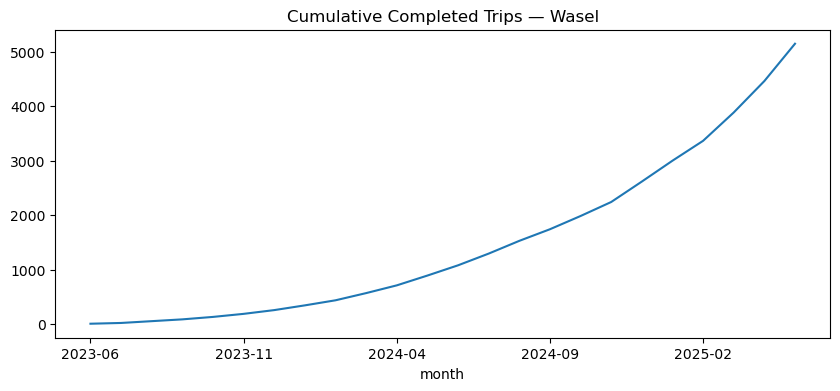

In [23]:
growth = result_growth.DataFrame()
growth.plot(x="month", y="running_total", figsize=(10, 4), title="Cumulative Completed Trips — Wasel", legend=False)

### Q16 — Is month-over-month trip growth accelerating or slowing?

**Business question:** the running total always goes up — what leadership actually wants to know is whether the *rate* is holding.

In [24]:
%%sql
WITH monthly AS (
    SELECT strftime('%Y-%m', pickup_time) AS month, COUNT(*) AS num_trips
    FROM trips
    WHERE status = 'completed'
    GROUP BY month
)
SELECT month, num_trips, num_trips - LAG(num_trips) OVER (ORDER BY month) AS change_from_prev_month
FROM monthly
ORDER BY month;

Running query in 'wasel'

month,num_trips,change_from_prev_month
2023-06,5,None
2023-07,14,9
2023-08,33,19
2023-09,33,0
2023-10,45,12
2023-11,56,11
2023-12,69,13
2024-01,87,18
2024-02,93,6
2024-03,132,39


### Q17 — Each top-earning driver's single best day.

**Business question:** if Wasel wants to feature a "driver of the month" story, this is where to find one worth telling.

In [25]:
%%sql
WITH daily AS (
    SELECT driver_id, DATE(pickup_time) AS day, SUM(fare_amount) AS day_earnings
    FROM trips
    WHERE status = 'completed'
    GROUP BY driver_id, day
),
ranked AS (
    SELECT driver_id, day, day_earnings,
           RANK() OVER (PARTITION BY driver_id ORDER BY day_earnings DESC) AS r
    FROM daily
)
SELECT d.driver_name, r.day, r.day_earnings
FROM ranked r
JOIN drivers d ON r.driver_id = d.driver_id
WHERE r.r = 1 AND d.driver_id IN (SELECT driver_id FROM top20_drivers)
ORDER BY r.day_earnings DESC
LIMIT 10;

Running query in 'wasel'

driver_name,day,day_earnings
Fatma Naguib,2025-03-19,692.17
Ashraf Zaki,2025-03-19,454.4
Hossam El-Shazly,2025-01-01,423.56
Salma Hamdy,2025-02-11,411.8
Sameh Farouk,2024-10-16,394.16
Rania Ragab,2023-11-17,374.14
Bassem Barakat,2025-03-14,370.13
Tarek Abdelrahman,2024-04-17,358.64
Mostafa Fahmy,2024-11-12,339.36
Ayman El-Kholy,2025-04-13,322.81


Last question set, before Randa signs off: is the rating data itself trustworthy enough to lean on?

### Q18 — What's the average rating riders give drivers, versus drivers give riders?

**Business question:** if one side rates noticeably harsher than the other, that's worth knowing before using ratings to justify a driver's incentive tier.

In [26]:
%%sql
SELECT rated_by, ROUND(AVG(rating), 2) AS avg_rating, COUNT(*) AS num_ratings
FROM ratings
GROUP BY rated_by;

Running query in 'wasel'

rated_by,avg_rating,num_ratings
driver,4.29,2247
rider,4.19,3553


Running query in 'wasel'

<Axes: title={'center': 'Ratings Given, by Who Rated'}>

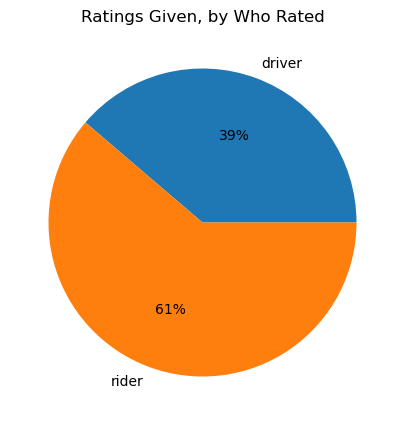

In [27]:
ratings_result = %sql SELECT rated_by, COUNT(*) AS n FROM ratings GROUP BY rated_by
ratings_df = ratings_result.DataFrame()
ratings_df.set_index("rated_by")["n"].plot(
    kind="pie", figsize=(5, 5), autopct="%1.0f%%", ylabel="", title="Ratings Given, by Who Rated"
)

### Q19 — How many completed trips have no rating at all, from either side?

**Business question:** ratings only mean something if there's enough of them — worth flagging the actual coverage before anyone builds a policy on top of "average rating".

In [28]:
%%sql
SELECT COUNT(*) AS unrated_completed_trips
FROM trips t
WHERE t.status = 'completed'
  AND NOT EXISTS (SELECT 1 FROM ratings r WHERE r.trip_id = t.trip_id);

Running query in 'wasel'

unrated_completed_trips
886


### Q20 — How many cities have driver coverage but zero completed trips there?

**Business question:** the coverage gap someone flagged in a meeting, checked properly — a city can have a driver "based" there on paper and still have no real activity.

In [29]:
%%sql
SELECT c.city_name
FROM cities c
WHERE EXISTS (SELECT 1 FROM drivers d WHERE d.home_city_id = c.city_id)
  AND NOT EXISTS (SELECT 1 FROM trips t WHERE t.pickup_city_id = c.city_id AND t.status = 'completed');

Running query in 'wasel'

city_name
Suez


**Insight:** Suez has exactly one driver on paper, and that driver is marked `inactive` — the "gap" isn't a demand problem, it's a supply problem with a one-line fix: activate or replace that single driver. Worth checking whether a red flag is a strategy problem or a data problem before recommending anything to leadership.

## Recap

Randa's recommendation writes itself from here: incentive budget goes to the cities in Q9/Q12 where trips are longer and more often cross-city (Giza, Alexandria — drivers there are doing more for the same fare), the promo codes in Q4 that aren't moving volume get retired, and Suez isn't a market problem, it's a one-driver staffing gap. Every technique used above — filtering, JOINs, CASE, anti-joins, subqueries, CTEs, a saved view, a temp table, and every window function from Day 05 — ran unchanged against a dataset built for a completely different business than Rawaj.